# Question 1

### AhmadReza Nopoush

610301194

## Data Prepration

In [1]:
import kagglehub
import pandas as pd
from pathlib import Path
from sklearn.model_selection import train_test_split
from collections import Counter
import torch
from torch.utils.data import Dataset, DataLoader

In [2]:
!pip install seqeval

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 4.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for seqeval: filename=seqeval-1.2.2-py3-none-any.whl size=16162 sha256=70cc3a9b8022225805ea26f442e8c237c622639658d172e7605879609794a03d
  Stored in directory: /root/.cache/pip/wheels/5f/b8/73/0b2c1a76b701a677653dd79ece07cfabd7457989dbfbdcd8d7
Successfully built seqeval


In [3]:
# LOAD DATA

path = kagglehub.dataset_download("siddhadev/atis-dataset-clean")
print("Downloaded files at:", path)

dataset_path = Path(path)

train_df = pd.read_csv(dataset_path / "atis.train.csv")
test_df  = pd.read_csv(dataset_path / "atis.test.csv")

print("Original Train size:", len(train_df))
print("Test size:", len(test_df))

# 10% SPLIT
train_df, val_df = train_test_split(train_df, test_size=0.1, random_state=42)

print("NEW Train size:", len(train_df))
print("Validation size:", len(val_df))
print("Test size:", len(test_df))

Using Colab cache for faster access to the 'atis-dataset-clean' dataset.
Downloaded files at: /kaggle/input/atis-dataset-clean
Original Train size: 4274
Test size: 586
NEW Train size: 3846
Validation size: 428
Test size: 586


In [4]:
# SHOW SAMPLE

sample = train_df.iloc[24]
print("Sentence:", sample["tokens"])
print("Slots:", sample["slots"])
print("Intent:", sample["intent"])

Sentence: BOS show me flights from milwaukee to orlando on wednesday night EOS
Slots: O O O O O B-fromloc.city_name O B-toloc.city_name O B-depart_date.day_name B-depart_time.period_of_day O
Intent: atis_flight


In [5]:
# TOKENIZATION & VOCAB

def tokenize(sentence):
    return sentence.split()

def tokenize_slots(slots):
    return slots.split()

PAD = "<PAD>"
UNK = "<UNK>"

word_counter = Counter()
slot_set = set()
intent_set = set()

for _, row in train_df.iterrows():
    tokens = tokenize(row["tokens"])
    slots = tokenize_slots(row["slots"])
    word_counter.update(tokens)
    slot_set.update(slots)
    intent_set.add(row["intent"])

# word vocab
word_vocab = {PAD: 0, UNK: 1}
for w in word_counter:
    word_vocab[w] = len(word_vocab)

# slot vocab
slot_vocab = {PAD: 0, UNK: 1}
for s in slot_set:
    slot_vocab[s] = len(slot_vocab)

# intent vocab
intent_vocab = {}
for i in intent_set:
    intent_vocab[i] = len(intent_vocab)

print("Word vocab size:", len(word_vocab))
print("Slot vocab size:", len(slot_vocab))
print("Intent vocab size:", len(intent_vocab))

Word vocab size: 837
Slot vocab size: 103
Intent vocab size: 17


In [6]:
# ENCODING / DECODING

def encode_words(tokens):
    return [word_vocab.get(t, word_vocab[UNK]) for t in tokens]

def encode_slots(slots):
    return [slot_vocab.get(s, slot_vocab[UNK]) for s in slots]

def encode_intent(intent):
    return intent_vocab[intent]

id2word = {v: k for k, v in word_vocab.items()}

def decode(seq):
    return [id2word[i] for i in seq]

In [7]:
# DATASET CLASS

class ATISDataset(Dataset):
    def __init__(self, df):
        self.df = df

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        words = tokenize(row["tokens"])
        slots = tokenize_slots(row["slots"])
        intent = row["intent"]

        return (
            encode_words(words),
            encode_slots(slots),
            encode_intent(intent)
        )

In [8]:
# COLLATE FUNCTIONS (PADDING)

# batch-level padding
def collate_batch(batch):
    word_seqs, slot_seqs, intents = zip(*batch)
    max_len = max(len(seq) for seq in word_seqs)

    padded_words = []
    padded_slots = []

    for w, s in zip(word_seqs, slot_seqs):
        pad_len = max_len - len(w)
        padded_words.append(w + [word_vocab[PAD]] * pad_len)
        padded_slots.append(s + [slot_vocab[PAD]] * pad_len)

    return (
        torch.tensor(padded_words),
        torch.tensor(padded_slots),
        torch.tensor(intents)
    )

# global dataset max padding
max_dataset_len = max(len(tokenize(row["tokens"])) for _, row in train_df.iterrows())

def collate_max_dataset(batch):
    word_seqs, slot_seqs, intents = zip(*batch)

    padded_words = []
    padded_slots = []

    for w, s in zip(word_seqs, slot_seqs):
        pad_len = max_dataset_len - len(w)
        padded_words.append(w + [word_vocab[PAD]] * pad_len)
        padded_slots.append(s + [slot_vocab[PAD]] * pad_len)

    return (
        torch.tensor(padded_words),
        torch.tensor(padded_slots),
        torch.tensor(intents)
    )

In [9]:
# DATA LOADERS

train_loader_batchpad = DataLoader(ATISDataset(train_df), batch_size=32, shuffle=True, collate_fn=collate_batch)
train_loader_fullpad = DataLoader(ATISDataset(train_df), batch_size=32, shuffle=True, collate_fn=collate_max_dataset)

val_loader = DataLoader(ATISDataset(val_df), batch_size=32, shuffle=False, collate_fn=collate_batch)
test_loader = DataLoader(ATISDataset(test_df), batch_size=32, shuffle=False, collate_fn=collate_batch)


# DEMONSTRATE PADDING DIFFERENCE

full_words, full_slots, _ = next(iter(train_loader_fullpad))
batch_words, batch_slots, _ = next(iter(train_loader_batchpad))

print("=== FULL PADDING EXAMPLE ===")
print("Token IDs:", full_words[0].tolist())
print("Decoded :", decode(full_words[0].tolist()))
print("Length:", len(full_words[0]))

print("\n=== BATCH PADDING EXAMPLE ===")
print("Token IDs:", batch_words[0].tolist())
print("Decoded :", decode(batch_words[0].tolist()))
print("Length:", len(batch_words[0]))

print("\nDifference in lengths:")
print(len(full_words[0]), "vs", len(batch_words[0]))


=== FULL PADDING EXAMPLE ===
Token IDs: [2, 159, 25, 138, 139, 13, 10, 16, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
Decoded : ['BOS', "what's", 'the', 'ground', 'transportation', 'in', 'denver', 'EOS', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>']
Length: 48

=== BATCH PADDING EXAMPLE ===
Token IDs: [2, 3, 30, 318, 16, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
Decoded : ['BOS', 'what', 'is', 'bna', 'EOS', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>']
Length: 20

Difference in lengths:
48 vs 20


## BiRNN

In [10]:
import torch
import torch.nn as nn
import torch.optim as optim
from seqeval.metrics import f1_score, classification_report
from tqdm import tqdm
import matplotlib.pyplot as plt
import numpy as np
import sklearn.metrics as metrics

### 1. MODEL ARCHITECTURE (Separate Classes)

In [11]:
class BiRNN_Intent(nn.Module):
    def __init__(self, vocab_size, num_intents, pad_idx, embedding_dim, hidden_dim, dropout):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=pad_idx)
        self.rnn = nn.RNN(
            input_size=embedding_dim,
            hidden_size=hidden_dim,
            batch_first=True,
            bidirectional=True,
        )
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim * 2, num_intents)

    def forward(self, x, mask):
        x = self.embedding(x)
        out, hidden = self.rnn(x)

        # Concatenate final forward and backward hidden states
        # hidden shape: (num_layers * num_directions, batch, hidden_dim)
        final = torch.cat((hidden[-2,:,:], hidden[-1,:,:]), dim=1)
        final = self.dropout(final)
        logits = self.fc(final)
        return logits

class BiRNN_Slot(nn.Module):
    def __init__(self, vocab_size, num_slots, pad_idx, embedding_dim, hidden_dim, dropout):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=pad_idx)
        self.rnn = nn.RNN(
            input_size=embedding_dim,
            hidden_size=hidden_dim,
            batch_first=True,
            bidirectional=True,
        )
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim * 2, num_slots)

    def forward(self, x, mask):
        x = self.embedding(x)
        out, _ = self.rnn(x)
        out = self.dropout(out)
        out = self.fc(out)
        return out

### 2. TRAINING & EVALUATION FUNCTIONS

In [12]:
def train_one_epoch(intent_model, slot_model, dataloader, intent_optimizer, slot_optimizer,
                    criterion_intent, criterion_slot, device, pad_idx):
    intent_model.train()
    slot_model.train()

    total_loss = 0.0
    correct_intent = 0
    total_intent = 0

    # Use tqdm for a progress bar
    pbar = tqdm(dataloader, desc="Training", leave=False)

    for words, slots, intents in pbar:
        words = words.to(device)
        slots = slots.to(device)
        intents = intents.to(device)

        mask = (words != pad_idx)

        # Zero grad for both optimizers
        intent_optimizer.zero_grad()
        slot_optimizer.zero_grad()

        # Forward pass
        intent_logits = intent_model(words, mask)
        slot_logits = slot_model(words, mask)

        # Calculate Losses
        loss_intent = criterion_intent(intent_logits, intents)

        # Reshape for slot loss
        batch_size, seq_len, num_slots = slot_logits.shape
        slot_logits_flat = slot_logits.view(batch_size * seq_len, num_slots)
        slots_flat = slots.view(batch_size * seq_len)
        loss_slot = criterion_slot(slot_logits_flat, slots_flat)

        # Joint Loss (Sum of two losses)
        loss = loss_intent + loss_slot

        # Backward pass
        loss.backward()
        intent_optimizer.step()
        slot_optimizer.step()

        # Statistics
        total_loss += loss.item()

        # Intent Accuracy Calculation
        _, predicted_intent = torch.max(intent_logits, 1)
        correct_intent += (predicted_intent == intents).sum().item()
        total_intent += intents.size(0)

        pbar.set_postfix({'loss': loss.item()})

    avg_loss = total_loss / len(dataloader)
    intent_acc = correct_intent / total_intent
    return avg_loss, intent_acc

def evaluate(intent_model, slot_model, dataloader, criterion_intent, criterion_slot, device, id2slot, id2intent, pad_idx):
    intent_model.eval()
    slot_model.eval()

    total_loss = 0.0
    correct_intent = 0
    total_intent = 0

    # For seqeval, we need lists of lists of tags (strings), not tensors
    all_pred_slots = []
    all_true_slots = []

    with torch.no_grad():
        for words, slots, intents in tqdm(dataloader, desc="Evaluating", leave=False):
            words = words.to(device)
            slots = slots.to(device)
            intents = intents.to(device)

            mask = (words != pad_idx)

            # Forward pass
            intent_logits = intent_model(words, mask)
            slot_logits = slot_model(words, mask)

            # --- Loss Calculation ---
            loss_intent = criterion_intent(intent_logits, intents)

            batch_size, seq_len, num_slots = slot_logits.shape
            slot_logits_flat = slot_logits.view(batch_size * seq_len, num_slots)
            slots_flat = slots.view(batch_size * seq_len)
            loss_slot = criterion_slot(slot_logits_flat, slots_flat)

            loss = loss_slot + loss_intent
            total_loss += loss.item()

            # --- Intent Accuracy ---
            _, predicted_intent = torch.max(intent_logits, 1)
            correct_intent += (predicted_intent == intents).sum().item()
            total_intent += intents.size(0)

            # --- Slot F1 Preparation ---
            # Get predicted slot IDs
            _, predicted_slots_ids = torch.max(slot_logits, dim=2) # (batch, seq_len)

            # Move to CPU to process with numpy/python lists
            predicted_slots_ids = predicted_slots_ids.cpu().numpy()
            slots_ids = slots.cpu().numpy()

            # Iterate over batch to remove padding and convert to strings
            for i in range(batch_size):
                true_seq = slots_ids[i]
                pred_seq = predicted_slots_ids[i]

                # Filter out padding (assuming 0 is PAD)
                length = len([t for t in true_seq if t != 0])

                # Slice only the valid part
                true_labels = [id2slot[t] for t in true_seq[:length]]
                pred_labels = [id2slot[t] for t in pred_seq[:length]]

                all_true_slots.append(true_labels)
                all_pred_slots.append(pred_labels)

    # Calculate Metrics
    avg_loss = total_loss / len(dataloader)
    intent_acc = correct_intent / total_intent

    # Seqeval F1 Score
    slot_f1 = f1_score(all_true_slots, all_pred_slots)

    return avg_loss, intent_acc, slot_f1, all_true_slots, all_pred_slots

def train_model(intent_model, slot_model, train_loader, val_loader, epochs, device, id2slot, id2intent,
                intent_optimizer, slot_optimizer, criterion_intent, criterion_slot, pad_idx):

    history = {
        'train_loss': [], 'train_intent_acc': [],
        'val_loss': [], 'val_intent_acc': [], 'val_slot_f1': []
    }

    best_val_f1 = 0.0

    print(f"Starting training on {device}...")

    for epoch in range(epochs):
        print(f"\nEpoch {epoch+1}/{epochs}")

        # Train
        train_loss, train_intent_acc = train_one_epoch(
            intent_model, slot_model, train_loader, intent_optimizer, slot_optimizer,
            criterion_intent, criterion_slot, device, pad_idx
        )

        # Validate
        val_loss, val_intent_acc, val_slot_f1, _, _ = evaluate(
            intent_model, slot_model, val_loader, criterion_intent, criterion_slot,
            device, id2slot, id2intent, pad_idx
        )

        # Save History
        history['train_loss'].append(train_loss)
        history['train_intent_acc'].append(train_intent_acc)
        history['val_loss'].append(val_loss)
        history['val_intent_acc'].append(val_intent_acc)
        history['val_slot_f1'].append(val_slot_f1)

        print(f"Train Loss: {train_loss:.4f} | Train Intent Acc: {train_intent_acc:.4f}")
        print(f"Val Loss:   {val_loss:.4f} | Val Intent Acc:   {val_intent_acc:.4f} | Val Slot F1: {val_slot_f1:.4f}")

        # Save best model (optional, based on Slot F1)
        if val_slot_f1 > best_val_f1:
            best_val_f1 = val_slot_f1
            torch.save(intent_model.state_dict(), "best_birnn_intent.pt")
            torch.save(slot_model.state_dict(), "best_birnn_slot.pt")
            print(f"  -> Saved new best models with F1: {val_slot_f1:.4f}")

    return history

### 3. MAIN EXECUTION


In [13]:
# Hyperparameters (From your original BiRNN code)
EMBEDDING_DIM = 128
HIDDEN_DIM = 128
DROPOUT = 0.5
NUM_EPOCHS = 10
LR = 0.001
BATCH_SIZE = 32

pad_idx = word_vocab["<PAD>"]
num_words = len(word_vocab)
num_slots = len(slot_vocab)
num_intents = len(intent_vocab)
print("Vocab sizes:", num_words, num_slots, num_intents)

# Initialize the models (Separate Instances)
intent_model = BiRNN_Intent(
    vocab_size=len(word_vocab),
    num_intents=len(intent_vocab),
    pad_idx=pad_idx,
    embedding_dim=EMBEDDING_DIM,
    hidden_dim=HIDDEN_DIM,
    dropout=DROPOUT
)

slot_model = BiRNN_Slot(
    vocab_size=len(word_vocab),
    num_slots=len(slot_vocab),
    pad_idx=pad_idx,
    embedding_dim=EMBEDDING_DIM,
    hidden_dim=HIDDEN_DIM,
    dropout=DROPOUT
)

# Move models to GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
intent_model.to(device)
slot_model.to(device)

criterion_slot = nn.CrossEntropyLoss(ignore_index=pad_idx)
criterion_intent = nn.CrossEntropyLoss()

# Separate Optimizers
intent_optimizer = optim.Adam(intent_model.parameters(), lr=LR)
slot_optimizer = optim.Adam(slot_model.parameters(), lr=LR)

# Create reverse mappings to convert IDs back to labels
id2slot = {v: k for k, v in slot_vocab.items()}
id2intent = {v: k for k, v in intent_vocab.items()}

# Run Training
history = train_model(
    intent_model,
    slot_model,
    train_loader_batchpad,  # Using batch padding loader defined previously
    val_loader,
    NUM_EPOCHS,
    device,
    id2slot,
    id2intent,
    intent_optimizer,
    slot_optimizer,
    criterion_intent,
    criterion_slot,
    pad_idx
)

Vocab sizes: 837 103 17
Starting training on cuda...

Epoch 1/10


Train Loss: 1.9251 | Train Intent Acc: 0.7681
Val Loss:   1.0182 | Val Intent Acc:   0.8107 | Val Slot F1: 0.7965
  -> Saved new best models with F1: 0.7965

Epoch 2/10


Train Loss: 0.8462 | Train Intent Acc: 0.8557
Val Loss:   0.7455 | Val Intent Acc:   0.8551 | Val Slot F1: 0.8572
  -> Saved new best models with F1: 0.8572

Epoch 3/10


Train Loss: 0.5608 | Train Intent Acc: 0.9056
Val Loss:   0.5364 | Val Intent Acc:   0.9112 | Val Slot F1: 0.8844
  -> Saved new best models with F1: 0.8844

Epoch 4/10


Train Loss: 0.4168 | Train Intent Acc: 0.9277
Val Loss:   0.4946 | Val Intent Acc:   0.9136 | Val Slot F1: 0.9074
  -> Saved new best models with F1: 0.9074

Epoch 5/10


...

Train Loss: 0.2740 | Train Intent Acc: 0.9496
Val Loss:   0.3758 | Val Intent Acc:   0.9252 | Val Slot F1: 0.9395
  -> Saved new best models with F1: 0.9395

Epoch 7/10


Train Loss: 0.2270 | Train Intent Acc: 0.9540
Val Loss:   0.3093 | Val Intent Acc:   0.9463 | Val Slot F1: 0.9468
  -> Saved new best models with F1: 0.9468

Epoch 8/10


Train Loss: 0.1581 | Train Intent Acc: 0.9730
Val Loss:   0.2745 | Val Intent Acc:   0.9533 | Val Slot F1: 0.9457

Epoch 9/10


Train Loss: 0.1226 | Train Intent Acc: 0.9787
Val Loss:   0.2636 | Val Intent Acc:   0.9556 | Val Slot F1: 0.9491
  -> Saved new best models with F1: 0.9491

Epoch 10/10


Train Loss: 0.0950 | Train Intent Acc: 0.9860
Val Loss:   0.2692 | Val Intent Acc:   0.9579 | Val Slot F1: 0.9526
  -> Saved new best models with F1: 0.9526


### 4. RESULTS

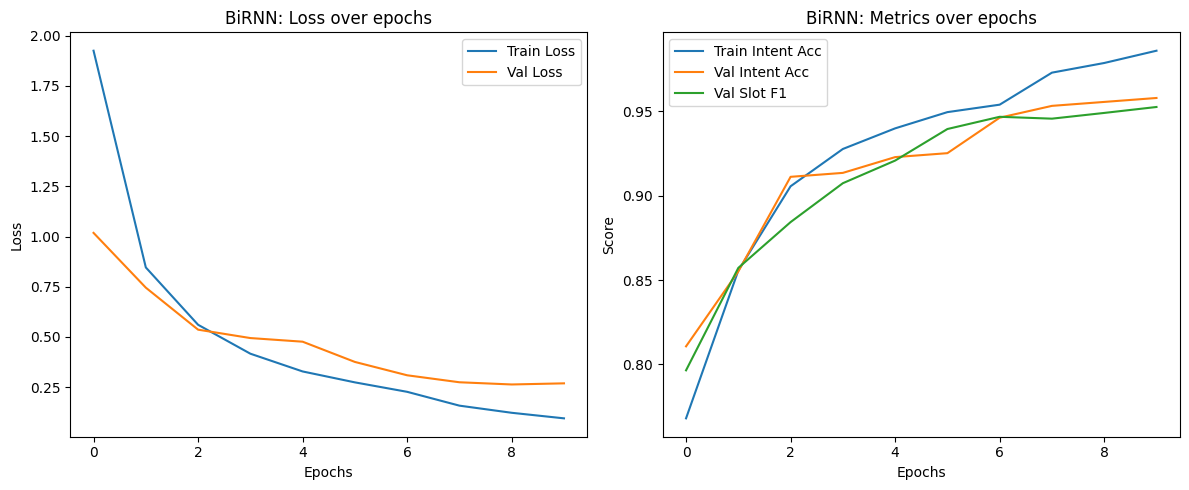

In [14]:
# --- PLOTTING ---
plt.figure(figsize=(12, 5))

# Plot Loss
plt.subplot(1, 2, 1)
plt.plot(history['train_loss'], label='Train Loss')
plt.plot(history['val_loss'], label='Val Loss')
plt.title('BiRNN: Loss over epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Plot Accuracy/F1
plt.subplot(1, 2, 2)
plt.plot(history['train_intent_acc'], label='Train Intent Acc')
plt.plot(history['val_intent_acc'], label='Val Intent Acc')
plt.plot(history['val_slot_f1'], label='Val Slot F1')
plt.title('BiRNN: Metrics over epochs')
plt.xlabel('Epochs')
plt.ylabel('Score')
plt.legend()

plt.tight_layout()
plt.show()

In [15]:
def evaluate_birnn(intent_model, slot_model, dataloader, criterion_intent, criterion_slot, device, id2slot, id2intent, pad_idx):
    intent_model.eval()
    slot_model.eval()

    total_loss = 0.0
    correct_intent = 0
    total_intent = 0

    all_pred_slots = []
    all_true_slots = []

    # NEW: Collect intent predictions
    all_pred_intents = []
    all_true_intents = []

    with torch.no_grad():
        for words, slots, intents in tqdm(dataloader, desc="Evaluating", leave=False):
            words = words.to(device)
            slots = slots.to(device)
            intents = intents.to(device)

            mask = (words != pad_idx)

            # Forward pass
            intent_logits = intent_model(words, mask)
            slot_logits = slot_model(words, mask)

            # --- Loss Calculation ---
            loss_intent = criterion_intent(intent_logits, intents)
            batch_size, seq_len, num_slots = slot_logits.shape
            slot_logits_flat = slot_logits.view(batch_size * seq_len, num_slots)
            slots_flat = slots.view(batch_size * seq_len)
            loss_slot = criterion_slot(slot_logits_flat, slots_flat)
            loss = loss_slot + loss_intent
            total_loss += loss.item()

            # --- Intent Accuracy & Tracking ---
            _, predicted_intent = torch.max(intent_logits, 1)
            correct_intent += (predicted_intent == intents).sum().item()
            total_intent += intents.size(0)

            # NEW: Store Intent Preds/Trues
            all_pred_intents.append(predicted_intent.cpu().numpy())
            all_true_intents.append(intents.cpu().numpy())

            # --- Slot F1 Preparation ---
            _, predicted_slots_ids = torch.max(slot_logits, dim=2)
            predicted_slots_ids = predicted_slots_ids.cpu().numpy()
            slots_ids = slots.cpu().numpy()

            for i in range(batch_size):
                true_seq = slots_ids[i]
                pred_seq = predicted_slots_ids[i]
                length = len([t for t in true_seq if t != 0])

                true_labels = [id2slot[t] for t in true_seq[:length]]
                pred_labels = [id2slot[t] for t in pred_seq[:length]]

                all_true_slots.append(true_labels)
                all_pred_slots.append(pred_labels)

    # Calculate Metrics
    avg_loss = total_loss / len(dataloader)
    intent_acc = correct_intent / total_intent
    slot_f1 = f1_score(all_true_slots, all_pred_slots)

    # NEW: Flatten intent lists for sklearn
    all_pred_intents = np.concatenate(all_pred_intents)
    all_true_intents = np.concatenate(all_true_intents)

    return avg_loss, intent_acc, slot_f1, all_true_slots, all_pred_slots, all_true_intents, all_pred_intents

In [16]:
# Load best models
intent_model.load_state_dict(torch.load("best_birnn_intent.pt"))
slot_model.load_state_dict(torch.load("best_birnn_slot.pt"))

# Run evaluate (unpack 7 items now)
test_loss, test_intent_acc, test_slot_f1, y_true_slots, y_pred_slots, y_true_intents, y_pred_intents = evaluate_birnn(
    intent_model, slot_model, test_loader, criterion_intent, criterion_slot, device, id2slot, id2intent, pad_idx
)

print("\n===== BiRNN TEST RESULTS =====")
print(f"Intent Accuracy: {test_intent_acc * 100:.2f}%")
print(f"Slot F1 Score:   {test_slot_f1 * 100:.2f}%")

# Intent Classification Report (Precision, Recall, F1)
print("\n===== INTENT CLASSIFICATION REPORT (BiRNN) =====")
target_names = [id2intent[i] for i in range(len(intent_vocab))]
print(metrics.classification_report(y_true_intents, y_pred_intents, target_names=target_names))


===== BiRNN TEST RESULTS =====
Intent Accuracy: 96.25%
Slot F1 Score:   94.79%

===== INTENT CLASSIFICATION REPORT (BiRNN) =====
                          precision    recall  f1-score   support

               atis_city       1.00      0.33      0.50         3
          atis_flight_no       1.00      0.50      0.67         2
           atis_capacity       1.00      1.00      1.00         4
        atis_ground_fare       1.00      0.75      0.86         4
atis_flight#atis_airfare       1.00      0.67      0.80         3
     atis_ground_service       0.94      1.00      0.97        29
           atis_distance       1.00      1.00      1.00         3
               atis_meal       0.00      0.00      0.00         1
             atis_flight       0.98      0.99      0.99       424
       atis_abbreviation       0.78      0.88      0.82        16
        atis_restriction       0.00      0.00      0.00         1
           atis_quantity       0.83      1.00      0.91         5
           

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [17]:
print("\n===== SLOT CLASSIFICATION REPORT (BiRNN) =====")
print(classification_report(y_true_slots, y_pred_slots))


===== SLOT CLASSIFICATION REPORT (BiRNN) =====
                            precision    recall  f1-score   support

             aircraft_code       0.67      0.86      0.75         7
              airline_code       1.00      0.95      0.98        22
              airline_name       0.97      0.98      0.97        91
              airport_code       0.60      0.75      0.67         4
              airport_name       0.44      0.50      0.47         8
 arrive_date.date_relative       0.00      0.00      0.00         1
      arrive_date.day_name       1.00      0.40      0.57        10
    arrive_date.day_number       1.00      0.86      0.92         7
    arrive_date.month_name       1.00      0.86      0.92         7
      arrive_time.end_time       1.00      0.67      0.80         3
    arrive_time.period_mod       0.00      0.00      0.00         1
 arrive_time.period_of_day       0.60      0.38      0.46         8
    arrive_time.start_time       1.00      0.67      0.80         3

/usr/local/lib/python3.12/dist-packages/seqeval/metrics/v1.py:57: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


In [18]:
def predict_and_print1(intent_model, slot_model, sentence, true_intent=None, true_slots_str=None, device='cpu'):
    # 1. Tokenize and Encode Input
    tokens = sentence.split()

    # Convert tokens to IDs. Use <UNK> (index 1) if word not in vocab
    word_ids = [word_vocab.get(t, word_vocab["<UNK>"]) for t in tokens]

    # 2. Prepare Tensor
    input_tensor = torch.tensor([word_ids]).to(device)
    mask = (input_tensor != 0)

    # 3. Model Inference
    intent_model.eval()
    slot_model.eval()
    with torch.no_grad():
        slot_logits, intent_logits = slot_model(input_tensor, mask), intent_model(input_tensor, mask)

    # 4. Decode Intent
    pred_intent_id = intent_logits.argmax(dim=1).item()
    pred_intent_label = id2intent[pred_intent_id]

    # 5. Decode Slots
    pred_slot_ids = slot_logits.argmax(dim=2).squeeze(0).tolist()

    # Convert IDs to Tags
    pred_slot_labels = [id2slot[i] for i in pred_slot_ids[:len(tokens)]]

    # Prepare True Labels (if provided)
    true_slot_labels = None
    if true_slots_str:
        true_slot_labels = true_slots_str.split()

    # 6. Print Results
    print("="*70)
    print(f"SENTENCE: {sentence}")
    print("-"*70)
    print(f"{'INTENT':<15} | {'PREDICTED':<20} | {'TRUE':<20}")
    print(f"{'':<15} | {pred_intent_label:<20} | {true_intent if true_intent else 'N/A':<20}")
    print("-"*70)
    print(f"{'TOKEN':<15} | {'PRED SLOT':<20} | {'TRUE SLOT':<20}")
    print("-"*70)

    for i, token in enumerate(tokens):
        p_slot = pred_slot_labels[i]
        t_slot = true_slot_labels[i] if true_slot_labels and i < len(true_slot_labels) else "N/A"
        print(f"{token:<15} | {p_slot:<20} | {t_slot:<20}")

    print("="*70)
    print()

# Example 1: Using a sample from the Test DataFrame
sample_idx = 189
test_sentence = test_df.iloc[sample_idx]['tokens']
test_true_intent = test_df.iloc[sample_idx]['intent']
test_true_slots = test_df.iloc[sample_idx]['slots']

predict_and_print1(
    intent_model,
    slot_model,
    test_sentence,
    true_intent=test_true_intent,
    true_slots_str=test_true_slots,
    device=device
)

# Example 2: A custom sentence (True labels unknown)
custom_sentence = "i want to fly from tehran to beijing"
print("Testing with a custom sentence:\n")
predict_and_print1(intent_model, slot_model, custom_sentence, device=device)

SENTENCE: BOS what airplane types fly from pittsburgh to baltimore EOS
----------------------------------------------------------------------
INTENT          | PREDICTED            | TRUE                
                | atis_flight          | atis_aircraft       
----------------------------------------------------------------------
TOKEN           | PRED SLOT            | TRUE SLOT           
----------------------------------------------------------------------
BOS             | O                    | O                   
what            | O                    | O                   
airplane        | O                    | O                   
types           | O                    | O                   
fly             | O                    | O                   
from            | O                    | O                   
pittsburgh      | B-fromloc.city_name  | B-fromloc.city_name 
to              | O                    | O                   
baltimore       | B-toloc.city_nam

## BiLSTM

In [19]:
import torch
import torch.nn as nn
import torch.optim as optim
from seqeval.metrics import f1_score, classification_report
from tqdm import tqdm
import matplotlib.pyplot as plt

### Model Architecture

In [20]:
class BiLSTM(nn.Module):
    def __init__(self, vocab_size, slot_size, intent_size, embedding_dim, hidden_dim, dropout):

        super(BiLSTM, self).__init__()

        # 1. Embedding Layer
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)

        # 2. BiLSTM Layer
        self.lstm = nn.LSTM(
            input_size=embedding_dim,
            hidden_size=hidden_dim,
            batch_first=True,
            bidirectional=True
        )

        # 3. Dropout Layer
        self.dropout = nn.Dropout(dropout)

        # 4. Intent Head (Linear)
        self.intent_head = nn.Linear(hidden_dim * 2, intent_size)

        # 5. Slot Head (Linear)
        self.slot_head = nn.Linear(hidden_dim * 2, slot_size)

    def forward(self, x):
        # Embedding
        embedded = self.embedding(x)  # Shape: (batch_size, seq_len, embedding_dim)

        # BiLSTM
        lstm_out, (h_n, c_n) = self.lstm(embedded)

        # Apply dropout to the LSTM outputs
        lstm_out = self.dropout(lstm_out)

        # Intent Detection
        h_forward = h_n[0]
        h_backward = h_n[1]
        intent_context = torch.cat((h_forward, h_backward), dim=1) # Shape: (batch_size, hidden_dim * 2)

        intent_logits = self.intent_head(self.dropout(intent_context)) # Shape: (batch_size, intent_size)

        # Slot Filling
        slot_logits = self.slot_head(lstm_out) # Shape: (batch_size, seq_len, slot_size)

        return slot_logits, intent_logits

### Training and Evaluation Functions

In [21]:
def train_one_epoch(model, dataloader, optimizer, criterion_slot, criterion_intent, device):
    model.train()
    total_loss = 0.0
    correct_intent = 0
    total_intent = 0

    # Use tqdm for a progress bar
    pbar = tqdm(dataloader, desc="Training", leave=False)

    for words, slots, intents in pbar:
        words = words.to(device)
        slots = slots.to(device)
        intents = intents.to(device)

        optimizer.zero_grad()

        # Forward pass
        slot_logits, intent_logits = model(words)

        # Calculate Intent Loss
        loss_intent = criterion_intent(intent_logits, intents)

        # Calculate Slot Loss
        batch_size, seq_len, num_slots = slot_logits.shape
        slot_logits_flat = slot_logits.view(batch_size * seq_len, num_slots)
        slots_flat = slots.view(batch_size * seq_len)

        loss_slot = criterion_slot(slot_logits_flat, slots_flat)

        # Joint Loss (Sum of two losses)
        loss = loss_slot + loss_intent

        # Backward pass
        loss.backward()
        optimizer.step()

        # Statistics
        total_loss += loss.item()

        # Intent Accuracy Calculation
        _, predicted_intent = torch.max(intent_logits, 1)
        correct_intent += (predicted_intent == intents).sum().item()
        total_intent += intents.size(0)

        pbar.set_postfix({'loss': loss.item()})

    avg_loss = total_loss / len(dataloader)
    intent_acc = correct_intent / total_intent
    return avg_loss, intent_acc

def evaluate(model, dataloader, criterion_slot, criterion_intent, device, id2slot, id2intent):
    model.eval()
    total_loss = 0.0
    correct_intent = 0
    total_intent = 0

    # For seqeval, we need lists of lists of tags (strings), not tensors
    all_pred_slots = []
    all_true_slots = []

    with torch.no_grad():
        for words, slots, intents in tqdm(dataloader, desc="Evaluating", leave=False):
            words = words.to(device)
            slots = slots.to(device)
            intents = intents.to(device)

            # Forward pass
            slot_logits, intent_logits = model(words)

            # --- Loss Calculation ---
            loss_intent = criterion_intent(intent_logits, intents)

            batch_size, seq_len, num_slots = slot_logits.shape
            slot_logits_flat = slot_logits.view(batch_size * seq_len, num_slots)
            slots_flat = slots.view(batch_size * seq_len)
            loss_slot = criterion_slot(slot_logits_flat, slots_flat)

            loss = loss_slot + loss_intent
            total_loss += loss.item()

            # --- Intent Accuracy ---
            _, predicted_intent = torch.max(intent_logits, 1)
            correct_intent += (predicted_intent == intents).sum().item()
            total_intent += intents.size(0)

            # --- Slot F1 Preparation ---
            # Get predicted slot IDs
            _, predicted_slots_ids = torch.max(slot_logits, dim=2) # (batch, seq_len)

            # Move to CPU to process with numpy/python lists
            predicted_slots_ids = predicted_slots_ids.cpu().numpy()
            slots_ids = slots.cpu().numpy()

            # Iterate over batch to remove padding and convert to strings
            for i in range(batch_size):
                true_seq = slots_ids[i]
                pred_seq = predicted_slots_ids[i]

                length = len([t for t in true_seq if t != 0])

                # Slice only the valid part
                true_labels = [id2slot[t] for t in true_seq[:length]]
                pred_labels = [id2slot[t] for t in pred_seq[:length]]

                all_true_slots.append(true_labels)
                all_pred_slots.append(pred_labels)

    # Calculate Metrics
    avg_loss = total_loss / len(dataloader)
    intent_acc = correct_intent / total_intent

    # Seqeval F1 Score
    slot_f1 = f1_score(all_true_slots, all_pred_slots)

    return avg_loss, intent_acc, slot_f1, all_true_slots, all_pred_slots

def train_model(model, train_loader, val_loader, epochs, device, id2slot, id2intent, optimizer, criterion_slot, criterion_intent):
    history = {
        'train_loss': [], 'train_intent_acc': [],
        'val_loss': [], 'val_intent_acc': [], 'val_slot_f1': []
    }

    best_val_f1 = 0.0

    print(f"Starting training on {device}...")

    for epoch in range(epochs):
        print(f"\nEpoch {epoch+1}/{epochs}")

        # Train
        train_loss, train_intent_acc = train_one_epoch(
            model, train_loader, optimizer, criterion_slot, criterion_intent, device
        )

        # Validate
        val_loss, val_intent_acc, val_slot_f1, _, _ = evaluate(
            model, val_loader, criterion_slot, criterion_intent, device, id2slot, id2intent
        )

        # Save History
        history['train_loss'].append(train_loss)
        history['train_intent_acc'].append(train_intent_acc)
        history['val_loss'].append(val_loss)
        history['val_intent_acc'].append(val_intent_acc)
        history['val_slot_f1'].append(val_slot_f1)

        print(f"Train Loss: {train_loss:.4f} | Train Intent Acc: {train_intent_acc:.4f}")
        print(f"Val Loss:   {val_loss:.4f} | Val Intent Acc:   {val_intent_acc:.4f} | Val Slot F1: {val_slot_f1:.4f}")

        # Save best model (optional, based on Slot F1)
        if val_slot_f1 > best_val_f1:
            best_val_f1 = val_slot_f1
            torch.save(model.state_dict(), "best_bilstm_model.pt")
            print(f"  -> Saved new best model with F1: {val_slot_f1:.4f}")

    return history

In [22]:
# Hyperparameters
EMBEDDING_DIM = 128
HIDDEN_DIM = 128
DROPOUT = 0.5
NUM_EPOCHS = 10
LR = 0.001
BATCH_SIZE = 32

pad_idx = word_vocab["<PAD>"]
num_words = len(word_vocab)
num_slots = len(slot_vocab)
num_intents = len(intent_vocab)
print("Vocab sizes:", num_words, num_slots, num_intents)

# Initialize the model
LSTM_model = BiLSTM(
    vocab_size=len(word_vocab),
    slot_size=len(slot_vocab),
    intent_size=len(intent_vocab),
    embedding_dim=EMBEDDING_DIM,
    hidden_dim=HIDDEN_DIM,
    dropout=DROPOUT
)

# Move model to GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
LSTM_model.to(device)
print(LSTM_model)

Vocab sizes: 837 103 17
BiLSTM(
  (embedding): Embedding(837, 128, padding_idx=0)
  (lstm): LSTM(128, 128, batch_first=True, bidirectional=True)
  (dropout): Dropout(p=0.5, inplace=False)
  (intent_head): Linear(in_features=256, out_features=17, bias=True)
  (slot_head): Linear(in_features=256, out_features=103, bias=True)
)


In [23]:
criterion_slot = nn.CrossEntropyLoss(ignore_index=pad_idx)
criterion_intent = nn.CrossEntropyLoss()

optimizer = optim.Adam(LSTM_model.parameters(), lr=LR)

# Create reverse mappings to convert IDs back to labels
id2slot = {v: k for k, v in slot_vocab.items()}
id2intent = {v: k for k, v in intent_vocab.items()}

# Run Training
history_BiLSTM = train_model(
    LSTM_model,
    train_loader_batchpad,  # Using batch padding loader defined previously
    val_loader,
    NUM_EPOCHS,
    device,
    id2slot,
    id2intent,
    optimizer,
    criterion_slot,
    criterion_intent
)

Starting training on cuda...

Epoch 1/10


Train Loss: 2.6033 | Train Intent Acc: 0.7473
Val Loss:   1.3275 | Val Intent Acc:   0.8435 | Val Slot F1: 0.6228
  -> Saved new best model with F1: 0.6228

Epoch 2/10


Train Loss: 0.9419 | Train Intent Acc: 0.8765
Val Loss:   0.7006 | Val Intent Acc:   0.9159 | Val Slot F1: 0.8254
  -> Saved new best model with F1: 0.8254

Epoch 3/10


Train Loss: 0.5373 | Train Intent Acc: 0.9345
Val Loss:   0.5158 | Val Intent Acc:   0.9299 | Val Slot F1: 0.8635
  -> Saved new best model with F1: 0.8635

Epoch 4/10


Train Loss: 0.3670 | Train Intent Acc: 0.9548
Val Loss:   0.3927 | Val Intent Acc:   0.9486 | Val Slot F1: 0.8888
  -> Saved new best model with F1: 0.8888

Epoch 5/10


...

Train Loss: 0.1862 | Train Intent Acc: 0.9849
Val Loss:   0.3023 | Val Intent Acc:   0.9509 | Val Slot F1: 0.9220
  -> Saved new best model with F1: 0.9220

Epoch 7/10


Train Loss: 0.1348 | Train Intent Acc: 0.9909
Val Loss:   0.2512 | Val Intent Acc:   0.9743 | Val Slot F1: 0.9382
  -> Saved new best model with F1: 0.9382

Epoch 8/10


Train Loss: 0.1051 | Train Intent Acc: 0.9935
Val Loss:   0.2298 | Val Intent Acc:   0.9696 | Val Slot F1: 0.9468
  -> Saved new best model with F1: 0.9468

Epoch 9/10


Train Loss: 0.0846 | Train Intent Acc: 0.9951
Val Loss:   0.3026 | Val Intent Acc:   0.9556 | Val Slot F1: 0.9498
  -> Saved new best model with F1: 0.9498

Epoch 10/10


Train Loss: 0.0672 | Train Intent Acc: 0.9979
Val Loss:   0.2453 | Val Intent Acc:   0.9673 | Val Slot F1: 0.9544
  -> Saved new best model with F1: 0.9544


### RESULTS

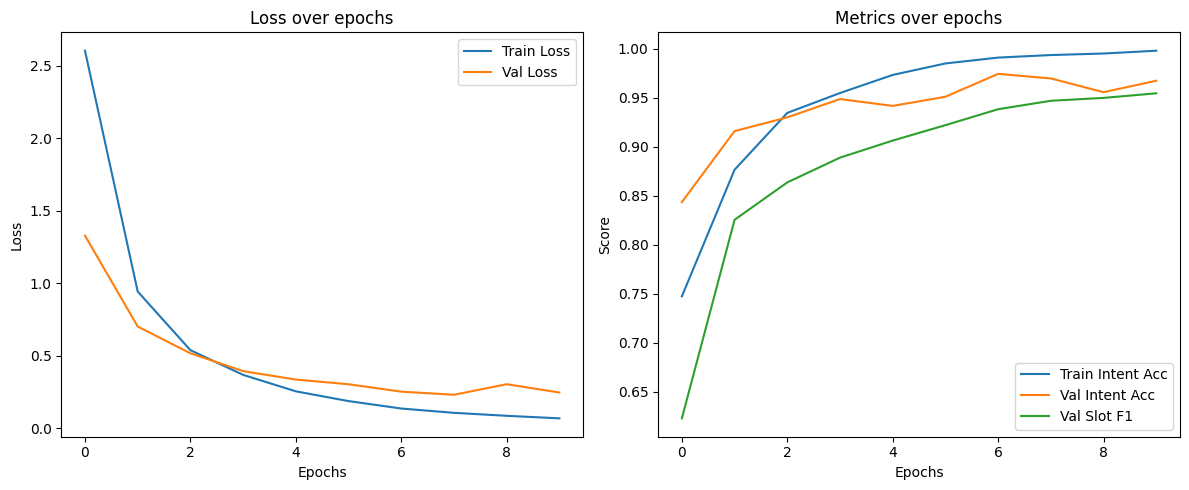

In [24]:
# --- PLOTTING (2-3-1) ---
plt.figure(figsize=(12, 5))

# Plot Loss
plt.subplot(1, 2, 1)
plt.plot(history_BiLSTM['train_loss'], label='Train Loss')
plt.plot(history_BiLSTM['val_loss'], label='Val Loss')
plt.title('Loss over epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Plot Accuracy/F1
plt.subplot(1, 2, 2)
plt.plot(history_BiLSTM['train_intent_acc'], label='Train Intent Acc')
plt.plot(history_BiLSTM['val_intent_acc'], label='Val Intent Acc')
plt.plot(history_BiLSTM['val_slot_f1'], label='Val Slot F1')
plt.title('Metrics over epochs')
plt.xlabel('Epochs')
plt.ylabel('Score')
plt.legend()

plt.tight_layout()
plt.show()

In [26]:
import numpy as np
import torch
from sklearn.metrics import classification_report as sklearn_classification_report
from seqeval.metrics import classification_report as seqeval_classification_report
from tqdm import tqdm

# --- 1. EVALUATION FUNCTION FOR BiLSTM ---

def evaluate_bilstm(model, dataloader, criterion_slot, criterion_intent, device, id2slot, id2intent):
    model.eval()

    total_loss = 0.0
    correct_intent = 0
    total_intent = 0

    all_pred_slots = []
    all_true_slots = []
    all_pred_intents = []
    all_true_intents = []

    with torch.no_grad():
        for words, slots, intents in tqdm(dataloader, desc="Evaluating", leave=False):
            words = words.to(device)
            slots = slots.to(device)
            intents = intents.to(device)

            # Forward pass (BiLSTM takes only words, returns both logits)
            slot_logits, intent_logits = model(words)

            # --- Loss Calculation ---
            loss_intent = criterion_intent(intent_logits, intents)

            batch_size, seq_len, num_slots = slot_logits.shape
            slot_logits_flat = slot_logits.view(batch_size * seq_len, num_slots)
            slots_flat = slots.view(batch_size * seq_len)

            loss_slot = criterion_slot(slot_logits_flat, slots_flat)
            loss = loss_slot + loss_intent
            total_loss += loss.item()

            # --- Intent Accuracy & Tracking ---
            _, predicted_intent = torch.max(intent_logits, 1)
            correct_intent += (predicted_intent == intents).sum().item()
            total_intent += intents.size(0)

            # Store Intent Preds/Trues
            all_pred_intents.append(predicted_intent.cpu().numpy())
            all_true_intents.append(intents.cpu().numpy())

            # --- Slot F1 Preparation ---
            _, predicted_slots_ids = torch.max(slot_logits, dim=2)
            predicted_slots_ids = predicted_slots_ids.cpu().numpy()
            slots_ids = slots.cpu().numpy()

            for i in range(batch_size):
                true_seq = slots_ids[i]
                pred_seq = predicted_slots_ids[i]
                length = len([t for t in true_seq if t != 0])

                true_labels = [id2slot[t] for t in true_seq[:length]]
                pred_labels = [id2slot[t] for t in pred_seq[:length]]

                all_true_slots.append(true_labels)
                all_pred_slots.append(pred_labels)

    # Calculate Metrics
    avg_loss = total_loss / len(dataloader)
    intent_acc = correct_intent / total_intent
    slot_f1 = f1_score(all_true_slots, all_pred_slots)

    # Flatten intent lists for sklearn
    all_pred_intents = np.concatenate(all_pred_intents)
    all_true_intents = np.concatenate(all_true_intents)

    return avg_loss, intent_acc, slot_f1, all_true_slots, all_pred_slots, all_true_intents, all_pred_intents


# --- 2. PREDICTION FUNCTION FOR BiLSTM ---

def predict_and_print_bilstm(model, sentence, true_intent=None, true_slots_str=None, device='cpu'):
    model.eval()

    # 1. Tokenize and Encode Input
    # Handle list-like strings if present in dataframe (e.g. "['i', 'want']")
    if isinstance(sentence, str) and sentence.startswith('['):
        sentence = sentence.replace("[", "").replace("]", "").replace("'", "").replace('"', "")

    tokens = sentence.split()

    # Convert tokens to IDs. Use <UNK> (index 1) if word not in vocab
    # Note: Ensure word_vocab is defined in your scope
    word_ids = [word_vocab.get(t, word_vocab["<UNK>"]) for t in tokens]

    # 2. Prepare Tensor
    input_tensor = torch.tensor([word_ids]).to(device)

    # 3. Model Inference
    with torch.no_grad():
        slot_logits, intent_logits = model(input_tensor)

    # 4. Decode Intent
    pred_intent_id = intent_logits.argmax(dim=1).item()
    pred_intent_label = id2intent[pred_intent_id]

    # 5. Decode Slots
    pred_slot_ids = slot_logits.argmax(dim=2).squeeze(0).tolist()

    # Convert IDs to Tags
    pred_slot_labels = [id2slot[i] for i in pred_slot_ids[:len(tokens)]]

    # Prepare True Labels (if provided)
    true_slot_labels = None
    if true_slots_str:
        if isinstance(true_slots_str, str) and true_slots_str.startswith('['):
            true_slots_str = true_slots_str.replace("[", "").replace("]", "").replace("'", "").replace('"', "")
        true_slot_labels = true_slots_str.split()

    # 6. Print Results
    print("="*70)
    print(f"SENTENCE: {' '.join(tokens)}")
    print("-"*70)
    print(f"{'INTENT':<15} | {'PREDICTED':<20} | {'TRUE':<20}")
    print(f"{'':<15} | {pred_intent_label:<20} | {true_intent if true_intent else 'N/A':<20}")
    print("-"*70)
    print(f"{'TOKEN':<15} | {'PRED SLOT':<20} | {'TRUE SLOT':<20}")
    print("-"*70)

    for i, token in enumerate(tokens):
        p_slot = pred_slot_labels[i]
        t_slot = true_slot_labels[i] if true_slot_labels and i < len(true_slot_labels) else "N/A"
        print(f"{token:<15} | {p_slot:<20} | {t_slot:<20}")

    print("="*70)
    print()


# --- 3. EXECUTION: LOAD MODEL, EVALUATE, PRINT REPORTS ---

# Load the best BiLSTM model (saved in your previous training step)
LSTM_model.load_state_dict(torch.load("best_bilstm_model.pt"))

# Run evaluation on the test set
test_loss, test_intent_acc, test_slot_f1, y_true_slots, y_pred_slots, y_true_intents, y_pred_intents = evaluate_bilstm(
    LSTM_model,
    test_loader,
    criterion_slot,
    criterion_intent,
    device,
    id2slot,
    id2intent
)

print("\n===== BiLSTM TEST RESULTS =====")
print(f"Intent Accuracy: {test_intent_acc * 100:.2f}%")
print(f"Slot F1 Score:   {test_slot_f1 * 100:.2f}%")

# Intent Classification Report (Precision, Recall, F1)
# FIX: Filter out special tokens to avoid ValueError
target_names = [k for k in id2intent.values() if k not in ['<UNK>', '<PAD>', '<SOS>', '<EOS>']]

print("\n===== INTENT CLASSIFICATION REPORT (BiLSTM) =====")
print(sklearn_classification_report(y_true_intents, y_pred_intents, target_names=target_names))

print("\n===== SLOT CLASSIFICATION REPORT (BiLSTM) =====")
print(seqeval_classification_report(y_true_slots, y_pred_slots))


# --- 4. INFERENCE EXAMPLES ---

# Example 1: Using a sample from the Test DataFrame
sample_idx = 189
test_sentence = test_df.iloc[sample_idx]['tokens']
test_true_intent = test_df.iloc[sample_idx]['intent']
test_true_slots = test_df.iloc[sample_idx]['slots']

print("\n===== SAMPLE INFERENCE FROM TEST SET =====")
predict_and_print_bilstm(
    LSTM_model,
    test_sentence,
    true_intent=test_true_intent,
    true_slots_str=test_true_slots,
    device=device
)

# Example 2: A custom sentence (True labels unknown)
custom_sentence = "i want to fly from tehran to beijing"
print("\n===== CUSTOM INFERENCE =====")
predict_and_print_bilstm(LSTM_model, custom_sentence, device=device)


===== BiLSTM TEST RESULTS =====
Intent Accuracy: 97.44%
Slot F1 Score:   94.06%

===== INTENT CLASSIFICATION REPORT (BiLSTM) =====
                          precision    recall  f1-score   support

               atis_city       1.00      0.67      0.80         3
          atis_flight_no       1.00      1.00      1.00         2
           atis_capacity       1.00      1.00      1.00         4
        atis_ground_fare       0.80      1.00      0.89         4
atis_flight#atis_airfare       0.75      1.00      0.86         3
     atis_ground_service       1.00      1.00      1.00        29
           atis_distance       1.00      0.67      0.80         3
               atis_meal       1.00      1.00      1.00         1
             atis_flight       0.98      0.99      0.99       424
       atis_abbreviation       0.93      0.88      0.90        16
        atis_restriction       0.00      0.00      0.00         1
           atis_quantity       0.83      1.00      0.91         5
         

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/seqeval/m

## Encoder Decoder

In [27]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torch.nn.utils.rnn import pad_sequence
from collections import Counter
import random
import math
import numpy as np
import time
import pandas as pd
from datasets import Dataset, DatasetDict
from seqeval.metrics import f1_score
from tqdm import tqdm
from sklearn.metrics import classification_report as sklearn_classification_report
from seqeval.metrics import classification_report as seqeval_classification_report

### Reprocessing data

In [28]:
# Convert Pandas to Hugging Face Datasets
dataset = DatasetDict({
    "train": Dataset.from_pandas(train_df),
    "validation": Dataset.from_pandas(val_df),
    "test": Dataset.from_pandas(test_df)
})

#TOKENIZATION
def simple_tokenizer(text):
    if isinstance(text, list):
        return text
    text = text.replace("[", "").replace("]", "").replace("'", "").replace('"', "")
    return text.split()

def tokenize_function(examples):
    return {
        "SRC": [simple_tokenizer(example) for example in examples["tokens"]],
        "TRG": [simple_tokenizer(example) for example in examples["slots"]],
    }

tokenized_dataset = dataset.map(tokenize_function, batched=True)

Map:   0%|          | 0/3846 [00:00<?, ? examples/s]

Map:   0%|          | 0/428 [00:00<?, ? examples/s]

Map:   0%|          | 0/586 [00:00<?, ? examples/s]

In [29]:
#BUILD VOCABULARIES
def build_vocab(tokenized_data, min_freq=2):
    vocab = {"<PAD>": 0, "<UNK>": 1, "<SOS>": 2, "<EOS>": 3}
    idx = 4
    token_counter = Counter(token for tokens in tokenized_data for token in tokens)
    for token, freq in token_counter.items():
        if freq >= min_freq and token not in vocab:
            vocab[token] = idx
            idx += 1
    return vocab

def build_intent_vocab(intent_data):
    # Unique intents + <UNK> for safety
    unique_intents = sorted(list(set(intent_data)))
    vocab = {intent: idx for idx, intent in enumerate(unique_intents)}
    vocab["<UNK>"] = len(vocab)
    return vocab

src_vocab = build_vocab(tokenized_dataset["train"]["SRC"])
trg_vocab = build_vocab(tokenized_dataset["train"]["TRG"])
intent_vocab = build_intent_vocab(tokenized_dataset["train"]["intent"])

print(f"Source Vocab Size: {len(src_vocab)}")
print(f"Target Vocab Size: {len(trg_vocab)}")
print(f"Intent Vocab Size: {len(intent_vocab)}")

Source Vocab Size: 592
Target Vocab Size: 102
Intent Vocab Size: 18


In [30]:
#NUMERICALIZE
def numericalize_seq(tokens, vocab):
    return [vocab["<SOS>"]] + [vocab.get(token, vocab["<UNK>"]) for token in tokens] + [vocab["<EOS>"]]

def numericalize_function(examples):
    return {
        "SRC": [numericalize_seq(tokens, src_vocab) for tokens in examples["SRC"]],
        "TRG": [numericalize_seq(tokens, trg_vocab) for tokens in examples["TRG"]],
        "INTENT": [intent_vocab.get(intent, intent_vocab["<UNK>"]) for intent in examples["intent"]]
    }

numericalized_dataset = tokenized_dataset.map(numericalize_function, batched=True)

#DATALOADERS
def collate_fn(batch):
    src = [torch.tensor(item["SRC"]) for item in batch]
    trg = [torch.tensor(item["TRG"]) for item in batch]
    intent = [torch.tensor(item["INTENT"]) for item in batch] # Scalar per item

    src_padded = pad_sequence(src, batch_first=True, padding_value=src_vocab["<PAD>"])
    trg_padded = pad_sequence(trg, batch_first=True, padding_value=trg_vocab["<PAD>"])

    intent_tensor = torch.stack(intent)

    return src_padded, trg_padded, intent_tensor

BATCH_SIZE = 32

train_loader = DataLoader(numericalized_dataset["train"], batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn)
val_loader = DataLoader(numericalized_dataset["validation"], batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn)
test_loader = DataLoader(numericalized_dataset["test"], batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn)

#CHECK OUTPUT
src_batch, trg_batch, intent_batch = next(iter(train_loader))

print(f"\nBatch Shapes:")
print(f"SRC (Tokens): {src_batch.shape}")
print(f"TRG (Slots):  {trg_batch.shape}")
print(f"INTENT:       {intent_batch.shape}")

print(f"\nSample Intent IDs in batch: {intent_batch[:5]}")

Map:   0%|          | 0/3846 [00:00<?, ? examples/s]

Map:   0%|          | 0/428 [00:00<?, ? examples/s]

Map:   0%|          | 0/586 [00:00<?, ? examples/s]


Batch Shapes:
SRC (Tokens): torch.Size([32, 24])
TRG (Slots):  torch.Size([32, 24])
INTENT:       torch.Size([32])

Sample Intent IDs in batch: tensor([ 8,  8,  8, 15,  8])


### Architecture

In [31]:
class Encoder(nn.Module):
    def __init__(self, input_dim, emb_dim, hid_dim, n_layers, device):
        super().__init__()
        self.hid_dim = hid_dim
        self.n_layers = n_layers
        self.embedding = nn.Embedding(input_dim, emb_dim)
        self.lstm = nn.LSTM(emb_dim, hid_dim, n_layers, batch_first=True)
        self.device = device

    def forward(self, src):
        # src dimension: (batch size, src len)
        embedded = self.embedding(src)
        # embedded dimension: (batch size, src len, emb dim)

        batch_size = src.shape[0]

        # Manual zero initialization of hidden and cell states
        hidden = torch.zeros(self.n_layers, batch_size, self.hid_dim).to(self.device)
        cell = torch.zeros(self.n_layers, batch_size, self.hid_dim).to(self.device)

        outputs, (hidden, cell) = self.lstm(embedded, (hidden, cell))

        return hidden, cell

class Decoder(nn.Module):
    def __init__(self, output_dim, emb_dim, hid_dim, n_layers, dropout):
        super().__init__()
        self.output_dim = output_dim
        self.hid_dim = hid_dim
        self.n_layers = n_layers

        # 1. Embedding Layer
        self.embedding = nn.Embedding(output_dim, emb_dim)

        # 2. LSTM Layer
        self.rnn = nn.LSTM(emb_dim, hid_dim, n_layers, batch_first=True)

        # 3. Dropout Layer (Applied before FC as per request)
        self.dropout = nn.Dropout(dropout)

        # Slot Head: Linear Layer
        self.fc_out = nn.Linear(hid_dim, output_dim)

    def forward(self, input, hidden, cell):
        # input dimension: (batch size)
        input = input.unsqueeze(1)
        # input dimension: (batch size, 1)

        embedded = self.embedding(input)
        # embedded dimension: (batch size, 1, emb dim)

        output, (hidden, cell) = self.rnn(embedded, (hidden, cell))
        # output dimension: (batch size, 1, hid dim)

        # Apply Dropout to the RNN output before passing to Linear layer
        dropped_output = self.dropout(output.squeeze(1))
        # dropped_output dimension: (batch size, hid dim)

        prediction = self.fc_out(dropped_output)
        # prediction dimension: (batch size, output_dim)

        return prediction, hidden, cell

class Seq2Seq(nn.Module):
    def __init__(self, encoder, decoder, intent_size, device):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.device = device

        # Projection Layers: Map Encoder Hidden/Cell to Decoder Dimensions
        self.encoder_hidden_projection = nn.Linear(encoder.hid_dim, decoder.hid_dim)
        self.encoder_cell_projection = nn.Linear(encoder.hid_dim, decoder.hid_dim)

        # Intent Head: Linear Layer
        self.intent_head = nn.Linear(decoder.hid_dim, intent_size)

    def forward(self, src, trg, teacher_forcing_ratio=0.5):
        batch_size = src.shape[0]
        trg_len = trg.shape[1]
        trg_vocab_size = self.decoder.output_dim

        # Tensor to store Slot predictions
        outputs = torch.zeros(batch_size, trg_len, trg_vocab_size).to(self.device)

        # 1. Encode Source
        hidden_enc, cell_enc = self.encoder(src)

        # 2. Project Encoder States to Decoder Dimensions
        hidden_dec = self.encoder_hidden_projection(hidden_enc.permute(1, 0, 2)).permute(1, 0, 2)
        cell_dec = self.encoder_cell_projection(cell_enc.permute(1, 0, 2)).permute(1, 0, 2)

        # 3. Predict Intent
        intent_logits = self.intent_head(hidden_dec[-1])

        # 4. Decode Slots (Sequence Generation)
        input = trg[:, 0]

        for t in range(1, trg_len):
            # Pass input, hidden, cell to decoder
            output, hidden_dec, cell_dec = self.decoder(input, hidden_dec, cell_dec)

            # Store Slot predictions
            outputs[:, t, :] = output

            # Teacher Forcing Logic
            teacher_force = random.random() < teacher_forcing_ratio

            # Get highest predicted token
            top1 = output.argmax(1)

            # If teacher forcing, use actual next token as next input
            input = trg[:, t] if teacher_force else top1

        return outputs, intent_logits

### Training & Evaluation functions

In [32]:
def train(model, dataloader, optimizer, criterion_slot, criterion_intent, clip, device, teacher_forcing_ratio=0.5):
    model.train()
    epoch_loss = 0
    correct_intent = 0
    total_intent = 0

    # Progress bar
    pbar = tqdm(dataloader, desc="Training", leave=False)

    for src, trg, intent in pbar:
        src = src.to(device)
        trg = trg.to(device)
        intent = intent.to(device)

        optimizer.zero_grad()

        # Forward pass
        output_slots, output_intent = model(src, trg, teacher_forcing_ratio)

        # We ignore <SOS> at index 0 (output[:, 1:])
        output_slot_dim = output_slots.shape[-1]

        # Reshape for CrossEntropy: (Batch * SeqLen, Vocab_Size)
        output_slots_flat = output_slots[:, 1:].reshape(-1, output_slot_dim)
        trg_slots_flat = trg[:, 1:].reshape(-1)

        loss_slot = criterion_slot(output_slots_flat, trg_slots_flat)

        loss_intent = criterion_intent(output_intent, intent)

        # --- Joint Loss ---
        loss = loss_slot + loss_intent

        loss.backward()

        # Gradient Clipping
        torch.nn.utils.clip_grad_norm_(model.parameters(), clip)

        optimizer.step()

        epoch_loss += loss.item()

        # --- Intent Accuracy ---
        _, predicted_intent = torch.max(output_intent, 1)
        correct_intent += (predicted_intent == intent).sum().item()
        total_intent += intent.size(0)

        pbar.set_postfix({'loss': f'{loss.item():.3f}'})

    return epoch_loss / len(dataloader), correct_intent / total_intent

def evaluate(model, dataloader, criterion_slot, criterion_intent, device, id2slot, pad_idx, eos_idx):
    model.eval()
    epoch_loss = 0
    correct_intent = 0
    total_intent = 0

    all_pred_slots = []
    all_true_slots = []

    with torch.no_grad():
        for src, trg, intent in tqdm(dataloader, desc="Evaluating", leave=False):
            src = src.to(device)
            trg = trg.to(device)
            intent = intent.to(device)

            # Forward pass (Teacher forcing = 0)
            output_slots, output_intent = model(src, trg, 0)

            # --- Loss Calculation ---
            output_slot_dim = output_slots.shape[-1]
            output_slots_flat = output_slots[:, 1:].reshape(-1, output_slot_dim)
            trg_slots_flat = trg[:, 1:].reshape(-1)

            loss_slot = criterion_slot(output_slots_flat, trg_slots_flat)
            loss_intent = criterion_intent(output_intent, intent)

            loss = loss_slot + loss_intent
            epoch_loss += loss.item()

            # --- Intent Accuracy ---
            _, predicted_intent = torch.max(output_intent, 1)
            correct_intent += (predicted_intent == intent).sum().item()
            total_intent += intent.size(0)

            # --- Slot F1 Calculation (String based) ---

            # Get predicted IDs (Batch, SeqLen-1)
            _, predicted_slots_ids = torch.max(output_slots[:, 1:, :], dim=2)

            # Move to CPU
            predicted_slots_ids = predicted_slots_ids.cpu().numpy()
            trg_ids = trg[:, 1:].cpu().numpy()

            batch_size = predicted_slots_ids.shape[0]

            for i in range(batch_size):
                # --- Process True Sequence ---
                # Filter out PAD and EOS tokens
                true_seq_ids = [t for t in trg_ids[i] if t != pad_idx and t != eos_idx]
                true_labels = [id2slot[t] for t in true_seq_ids]

                # --- Process Predicted Sequence ---
                pred_seq_ids = []
                for p in predicted_slots_ids[i]:
                    if p == pad_idx or p == eos_idx:
                        break
                    pred_seq_ids.append(p)

                pred_labels = [id2slot[p] for p in pred_seq_ids]

                # --- Alignment ---
                # seqeval requires strictly equal list lengths

                # Case 1: Prediction is shorter than truth -> Pad with 'O'
                if len(pred_labels) < len(true_labels):
                    pred_labels.extend(['O'] * (len(true_labels) - len(pred_labels)))

                # Case 2: Prediction is longer than truth -> Truncate
                elif len(pred_labels) > len(true_labels):
                    pred_labels = pred_labels[:len(true_labels)]

                all_true_slots.append(true_labels)
                all_pred_slots.append(pred_labels)

    # Calculate F1
    slot_f1 = f1_score(all_true_slots, all_pred_slots)

    return epoch_loss / len(dataloader), correct_intent / total_intent, slot_f1

### Train the Model

In [33]:
def epoch_time(start_time, end_time):
    elapsed_time = end_time - start_time
    elapsed_mins = int(elapsed_time / 60)
    elapsed_secs = int(elapsed_time - (elapsed_mins * 60))
    return elapsed_mins, elapsed_secs

def get_id2label(vocab):
    """Reverse mapping from ID to Label string."""
    return {idx: label for label, idx in vocab.items()}

# Generate the specific ID maps needed for Slot F1 evaluation
id2slot = get_id2label(trg_vocab)

# Extract special indices explicitly to avoid hard-coding
PAD_IDX = trg_vocab["<PAD>"]
EOS_IDX = trg_vocab["<EOS>"]
SOS_IDX = trg_vocab["<SOS>"]

In [38]:
# Hyperparameters
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
EPOCHS = 20

INPUT_DIM = len(src_vocab)
OUTPUT_DIM = len(trg_vocab)
INTENT_DIM = len(intent_vocab)
ENC_EMB_DIM = 128
DEC_EMB_DIM = 64
ENC_HID_DIM = 128
DEC_HID_DIM = 256
N_LAYERS = 1
DROPOUT = 0.5
LEARNING_RATE = 0.003

CLIP = 5
TEACHER_FORCING_RATIO = 0.3

# Initialize Models
enc = Encoder(INPUT_DIM, ENC_EMB_DIM, ENC_HID_DIM, N_LAYERS, device)
dec = Decoder(OUTPUT_DIM, DEC_EMB_DIM, DEC_HID_DIM, N_LAYERS, DROPOUT)

seq2seq = Seq2Seq(enc, dec, INTENT_DIM, device).to(device)

# Loss Functions
criterion_slots = nn.CrossEntropyLoss(ignore_index=trg_vocab["<PAD>"])
criterion_intent = nn.CrossEntropyLoss()

# Optimizer
optimizer = optim.Adam(seq2seq.parameters(), lr=LEARNING_RATE)

In [39]:
best_valid_f1 = -float('inf') # Initialize to negative infinity

# History storage
history_seq2seq = {
    'train_loss': [], 'train_intent_acc': [],
    'val_loss': [], 'val_intent_acc': [], 'val_slot_f1': []
}

print(f"Starting Training on {device} for {EPOCHS} epochs...")

for epoch in range(EPOCHS):
    start_time = time.time()

    # --- Train ---
    train_loss, train_acc = train(
        seq2seq,
        train_loader,
        optimizer,
        criterion_slots,
        criterion_intent,
        CLIP,
        device,
        teacher_forcing_ratio=TEACHER_FORCING_RATIO
    )

    # --- Evaluate ---
    # Pass pad_idx and eos_idx explicitly
    val_loss, val_acc, val_f1 = evaluate(
        seq2seq,
        val_loader,
        criterion_slots,
        criterion_intent,
        device,
        id2slot,
        pad_idx=PAD_IDX,
        eos_idx=EOS_IDX
    )

    end_time = time.time()
    epoch_mins, epoch_secs = epoch_time(start_time, end_time)

    # --- Store History ---
    history_seq2seq['train_loss'].append(train_loss)
    history_seq2seq['train_intent_acc'].append(train_acc)
    history_seq2seq['val_loss'].append(val_loss)
    history_seq2seq['val_intent_acc'].append(val_acc)
    history_seq2seq['val_slot_f1'].append(val_f1)

    # --- Print Stats ---
    print(f"Epoch: {epoch+1:02} | Time: {epoch_mins}m {epoch_secs}s")
    print(f"\tTrain Loss: {train_loss:.3f} | Train Intent Acc: {train_acc*100:.2f}%")
    print(f"\tVal   Loss: {val_loss:.3f} | Val   Intent Acc: {val_acc*100:.2f}% | Val Slot F1: {val_f1*100:.2f}%")

    # --- Save Best Model ---
    if val_f1 > best_valid_f1:
        best_valid_f1 = val_f1
        torch.save(seq2seq.state_dict(), 'best-model.pt')
        print(f"\t*** Saved new best model (Val F1: {val_f1:.4f}) ***")

print("Training complete.")

Starting Training on cuda for 20 epochs...


Epoch: 01 | Time: 0m 5s
	Train Loss: 2.839 | Train Intent Acc: 73.50%
	Val   Loss: 2.615 | Val   Intent Acc: 75.23% | Val Slot F1: 0.00%
	*** Saved new best model (Val F1: 0.0000) ***


Epoch: 02 | Time: 0m 5s
	Train Loss: 2.244 | Train Intent Acc: 77.56%
	Val   Loss: 2.098 | Val   Intent Acc: 81.54% | Val Slot F1: 1.59%
	*** Saved new best model (Val F1: 0.0159) ***


Epoch: 03 | Time: 0m 5s
	Train Loss: 1.738 | Train Intent Acc: 86.64%
	Val   Loss: 1.778 | Val   Intent Acc: 88.32% | Val Slot F1: 23.41%
	*** Saved new best model (Val F1: 0.2341) ***


Epoch: 04 | Time: 0m 5s
	Train Loss: 1.460 | Train Intent Acc: 89.42%
	Val   Loss: 1.566 | Val   Intent Acc: 87.62% | Val Slot F1: 36.35%
	*** Saved new best model (Val F1: 0.3635) ***


...

Epoch: 16 | Time: 0m 6s
	Train Loss: 0.727 | Train Intent Acc: 99.40%
	Val   Loss: 1.095 | Val   Intent Acc: 96.50% | Val Slot F1: 50.42%


Epoch: 17 | Time: 0m 5s
	Train Loss: 0.687 | Train Intent Acc: 99.43%
	Val   Loss: 1.156 | Val   Intent Acc: 96.26% | Val Slot F1: 52.23%
	*** Saved new best model (Val F1: 0.5223) ***


Epoch: 18 | Time: 0m 6s
	Train Loss: 0.675 | Train Intent Acc: 99.77%
	Val   Loss: 1.051 | Val   Intent Acc: 96.26% | Val Slot F1: 53.17%
	*** Saved new best model (Val F1: 0.5317) ***


Epoch: 19 | Time: 0m 5s
	Train Loss: 0.661 | Train Intent Acc: 99.87%
	Val   Loss: 1.128 | Val   Intent Acc: 96.50% | Val Slot F1: 43.20%


Epoch: 20 | Time: 0m 6s
	Train Loss: 0.638 | Train Intent Acc: 99.97%
	Val   Loss: 1.042 | Val   Intent Acc: 96.26% | Val Slot F1: 53.64%
	*** Saved new best model (Val F1: 0.5364) ***
Training complete.


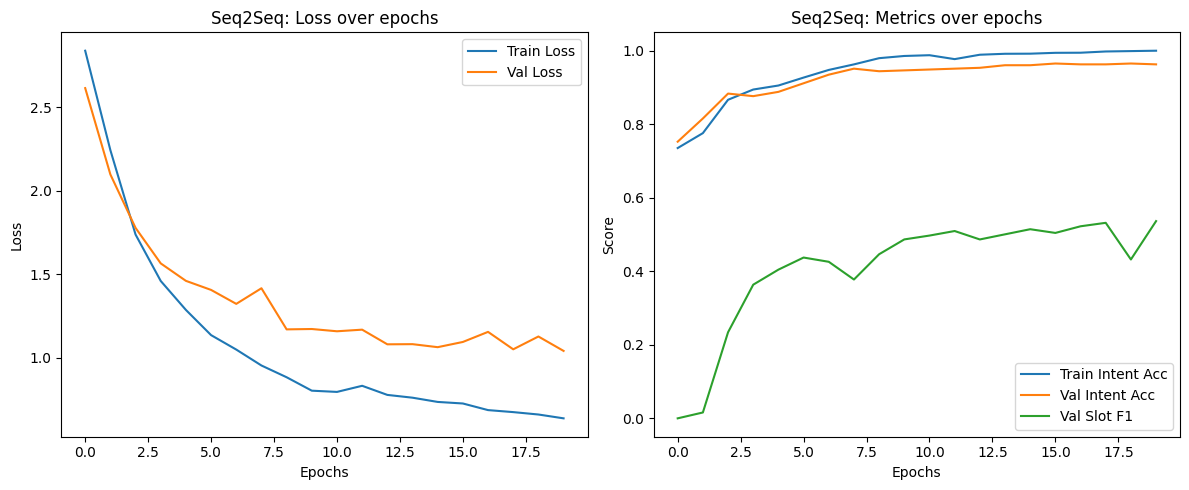

In [40]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

# Loss Plot
plt.subplot(1, 2, 1)
plt.plot(history_seq2seq['train_loss'], label='Train Loss')
plt.plot(history_seq2seq['val_loss'], label='Val Loss')
plt.title('Seq2Seq: Loss over epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Metrics Plot
plt.subplot(1, 2, 2)
plt.plot(history_seq2seq['train_intent_acc'], label='Train Intent Acc')
plt.plot(history_seq2seq['val_intent_acc'], label='Val Intent Acc')
plt.plot(history_seq2seq['val_slot_f1'], label='Val Slot F1')
plt.title('Seq2Seq: Metrics over epochs')
plt.xlabel('Epochs')
plt.ylabel('Score')
plt.legend()

plt.tight_layout()
plt.show()

### Results

In [41]:
id2intent = {idx: label for label, idx in intent_vocab.items()}

# EVALUATION FUNCTION ---

def evaluate_seq2seq_joint(model, dataloader, criterion_slot, criterion_intent, device, id2slot, id2intent, pad_idx, eos_idx):
    model.eval()

    total_loss = 0.0
    correct_intent = 0
    total_intent = 0

    all_pred_slots = []
    all_true_slots = []
    all_pred_intents = []
    all_true_intents = []

    with torch.no_grad():
        for src, trg, intent in tqdm(dataloader, desc="Evaluating", leave=False):
            src = src.to(device)
            trg = trg.to(device)
            intent = intent.to(device)

            # Forward pass
            output_slots, output_intent = model(src, trg, teacher_forcing_ratio=0)

            # --- Loss Calculation ---
            output_slot_dim = output_slots.shape[-1]

            output_slots_flat = output_slots[:, 1:].reshape(-1, output_slot_dim)
            trg_slots_flat = trg[:, 1:].reshape(-1)

            loss_slot = criterion_slot(output_slots_flat, trg_slots_flat)
            loss_intent = criterion_intent(output_intent, intent)

            loss = loss_slot + loss_intent
            total_loss += loss.item()

            # --- Intent Accuracy & Collection ---
            _, predicted_intent = torch.max(output_intent, 1)
            correct_intent += (predicted_intent == intent).sum().item()
            total_intent += intent.size(0)

            all_pred_intents.append(predicted_intent.cpu().numpy())
            all_true_intents.append(intent.cpu().numpy())

            # --- Slot F1 Preparation ---
            _, predicted_slots_ids = torch.max(output_slots[:, 1:, :], dim=2)

            predicted_slots_ids = predicted_slots_ids.cpu().numpy()
            trg_ids = trg[:, 1:].cpu().numpy()

            batch_size = predicted_slots_ids.shape[0]

            for i in range(batch_size):
                # --- True Sequence ---
                true_seq_ids = [t for t in trg_ids[i] if t != pad_idx and t != eos_idx]
                true_labels = [id2slot[t] for t in true_seq_ids]

                # --- Predicted Sequence ---
                pred_seq_ids = []
                for p in predicted_slots_ids[i]:
                    if p == pad_idx or p == eos_idx:
                        break
                    pred_seq_ids.append(p)

                pred_labels = [id2slot[p] for p in pred_seq_ids]

                # --- Alignment ---
                if len(pred_labels) < len(true_labels):
                    pred_labels.extend(['O'] * (len(true_labels) - len(pred_labels)))
                elif len(pred_labels) > len(true_labels):
                    pred_labels = pred_labels[:len(true_labels)]

                all_true_slots.append(true_labels)
                all_pred_slots.append(pred_labels)

    # --- Calculate Metrics ---
    avg_loss = total_loss / len(dataloader)
    intent_acc = correct_intent / total_intent
    slot_f1 = f1_score(all_true_slots, all_pred_slots)

    # Flatten intent lists for sklearn
    all_pred_intents = np.concatenate(all_pred_intents)
    all_true_intents = np.concatenate(all_true_intents)

    return avg_loss, intent_acc, slot_f1, all_true_slots, all_pred_slots, all_true_intents, all_pred_intents


# --- 2. PREDICTION FUNCTION ---

def predict_and_print(model, sentence, src_vocab, trg_vocab, intent_vocab, id2slot, id2intent, true_intent=None, true_slots_str=None, device='cpu'):
    model.eval()

    # 1. Tokenize and Numericalize
    # Handle list-like strings if present in dataframe (e.g. "['i', 'want']")
    if isinstance(sentence, str) and sentence.startswith('['):
        sentence = sentence.replace("[", "").replace("]", "").replace("'", "").replace('"', "")

    tokens = sentence.split()

    # Convert to IDs
    src_ids = [src_vocab.get(t, src_vocab["<UNK>"]) for t in tokens]

    # Create Tensor (1, Seq_Len)
    src_tensor = torch.LongTensor([src_ids]).to(device)

    # 2. Prepare Dummy Target for Inference
    # The Seq2Seq model requires a target tensor.
    # We create a dummy tensor starting with <SOS>.
    # With teacher_forcing_ratio=0, the model ignores the rest of this tensor.
    max_len = len(tokens) + 10 # Buffer for generation
    dummy_trg = torch.LongTensor([[trg_vocab["<SOS>"]] + [trg_vocab["<PAD>"]] * (max_len - 1)]).to(device)

    with torch.no_grad():
        output_slots, output_intent = model(src_tensor, dummy_trg, teacher_forcing_ratio=0)

    # 3. Decode Intent
    pred_intent_id = output_intent.argmax(1).item()
    pred_intent_label = id2intent[pred_intent_id]

    # 4. Decode Slots (THE FIX)
    # output_slots shape: (1, max_len, slot_vocab_size)
    # We slice [:, 1:, :] because the model stores predictions starting at index 1 (skipping the zero-initialization)
    pred_logits = output_slots[:, 1:, :]
    pred_slot_ids = pred_logits.argmax(2).squeeze(0).cpu().tolist()

    # Filter: Stop at EOS or PAD
    valid_pred_slots = []
    for sid in pred_slot_ids:
        if sid == trg_vocab["<EOS>"] or sid == trg_vocab["<PAD>"]:
            break
        valid_pred_slots.append(sid)

    # Ensure prediction list length matches input token length for alignment
    # If model predicted fewer, pad with 'O'. If more, truncate.
    if len(valid_pred_slots) < len(tokens):
        valid_pred_slots.extend([trg_vocab.get('O', trg_vocab["<PAD>"])] * (len(tokens) - len(valid_pred_slots)))
    elif len(valid_pred_slots) > len(tokens):
        valid_pred_slots = valid_pred_slots[:len(tokens)]

    # Convert IDs to Tags
    pred_slot_labels = [id2slot[i] for i in valid_pred_slots]

    # Prepare True Labels (if provided)
    true_slot_labels = []
    if true_slots_str:
        # Handle list-like string format for true slots as well
        if isinstance(true_slots_str, str) and true_slots_str.startswith('['):
            true_slots_str = true_slots_str.replace("[", "").replace("]", "").replace("'", "").replace('"', "")
        true_slot_labels = true_slots_str.split()

    # 5. Print Results
    print("="*80)
    print(f"SENTENCE: {' '.join(tokens)}") # Print cleaned tokens
    print("-"*80)
    print(f"{'INTENT':<15} | {'PREDICTED':<25} | {'TRUE':<25}")
    print(f"{'':<15} | {pred_intent_label:<25} | {true_intent if true_intent else 'N/A':<25}")
    print("-"*80)
    print(f"{'TOKEN':<15} | {'PRED SLOT':<25} | {'TRUE SLOT':<25}")
    print("-"*80)

    # Print alignment
    for i in range(len(tokens)):
        token = tokens[i]
        p_slot = pred_slot_labels[i] if i < len(pred_slot_labels) else "N/A"
        t_slot = true_slot_labels[i] if true_slot_labels and i < len(true_slot_labels) else "N/A"
        print(f"{token:<15} | {p_slot:<25} | {t_slot:<25}")

    print("="*80)
    print()


In [42]:
print("\n===== SEQ2SEQ TEST RESULTS =====")

# Run evaluation on the test set
test_loss, test_intent_acc, test_slot_f1, y_true_slots, y_pred_slots, y_true_intents, y_pred_intents = evaluate_seq2seq_joint(
    seq2seq,
    test_loader,
    criterion_slots,
    criterion_intent,
    device,
    id2slot,
    id2intent,
    pad_idx=PAD_IDX,
    eos_idx=EOS_IDX
)

print(f"\nOverall Intent Accuracy: {test_intent_acc * 100:.2f}%")
print(f"\nOverall Slot F1 Score:   {test_slot_f1 * 100:.2f}%")


===== SEQ2SEQ TEST RESULTS =====



Overall Intent Accuracy: 96.42%

Overall Slot F1 Score:   54.27%


In [43]:
# Intent Classification Report
target_names = [label for label in id2intent.values() if label not in ['<UNK>', '<PAD>', '<SOS>', '<EOS>']]

print("\n===== INTENT CLASSIFICATION REPORT =====")
print(sklearn_classification_report(y_true_intents, y_pred_intents, target_names=target_names))


===== INTENT CLASSIFICATION REPORT =====
                          precision    recall  f1-score   support

       atis_abbreviation       0.88      0.88      0.88        16
           atis_aircraft       0.75      0.75      0.75         8
            atis_airfare       0.96      0.96      0.96        54
            atis_airline       0.90      1.00      0.95        18
            atis_airport       1.00      0.75      0.86         4
           atis_capacity       1.00      1.00      1.00         4
               atis_city       1.00      0.67      0.80         3
           atis_distance       1.00      1.00      1.00         3
             atis_flight       0.99      0.99      0.99       424
atis_flight#atis_airfare       0.40      0.67      0.50         3
          atis_flight_no       1.00      0.50      0.67         2
        atis_flight_time       1.00      0.57      0.73         7
        atis_ground_fare       1.00      0.75      0.86         4
     atis_ground_service       0.

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [44]:
# Slot Classification Report (Seqeval - Entity based)
print("\n===== SLOT CLASSIFICATION REPORT =====")
print(seqeval_classification_report(y_true_slots, y_pred_slots))


===== SLOT CLASSIFICATION REPORT =====
                            precision    recall  f1-score   support

                      UNK>       0.00      0.00      0.00         2
             aircraft_code       0.00      0.00      0.00         7
              airline_code       0.60      0.14      0.22        22
              airline_name       0.06      0.02      0.03        91
              airport_code       1.00      0.50      0.67         4
              airport_name       0.00      0.00      0.00         8
 arrive_date.date_relative       0.00      0.00      0.00         1
      arrive_date.day_name       0.00      0.00      0.00        10
    arrive_date.day_number       0.00      0.00      0.00         7
    arrive_date.month_name       0.00      0.00      0.00         7
      arrive_time.end_time       0.00      0.00      0.00         3
    arrive_time.period_mod       0.00      0.00      0.00         1
 arrive_time.period_of_day       0.00      0.00      0.00         8
    arr

/usr/local/lib/python3.12/dist-packages/seqeval/metrics/sequence_labeling.py:171: UserWarning: <UNK> seems not to be NE tag.
  warnings.warn('{} seems not to be NE tag.'.format(chunk))
/usr/local/lib/python3.12/dist-packages/seqeval/metrics/v1.py:57: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


In [45]:
# --- 4. INFERENCE EXAMPLES ---

# Load best weights if not already loaded
seq2seq.load_state_dict(torch.load("best-model.pt"))

# Example 1: From Test Data
sample_idx = 123
test_sentence = test_df.iloc[sample_idx]['tokens']
test_true_intent = test_df.iloc[sample_idx]['intent']
test_true_slots = test_df.iloc[sample_idx]['slots']

print("\n===== SAMPLE INFERENCE FROM TEST SET =====")
predict_and_print(
    seq2seq,
    test_sentence,
    src_vocab,
    trg_vocab,
    intent_vocab,
    id2slot,
    id2intent,
    true_intent=test_true_intent,
    true_slots_str=test_true_slots,
    device=device
)

# Example 2: Custom Sentence
custom_sentence = "i want to travel from tehran to beijing"
print("\n===== CUSTOM INFERENCE =====")
predict_and_print(
    seq2seq,
    custom_sentence,
    src_vocab,
    trg_vocab,
    intent_vocab,
    id2slot,
    id2intent,
    device=device
)


===== SAMPLE INFERENCE FROM TEST SET =====
SENTENCE: BOS i'd need information please on a flight from washington dc san francisco california EOS
--------------------------------------------------------------------------------
INTENT          | PREDICTED                 | TRUE                     
                | atis_flight               | atis_flight              
--------------------------------------------------------------------------------
TOKEN           | PRED SLOT                 | TRUE SLOT                
--------------------------------------------------------------------------------
BOS             | O                         | O                        
i'd             | O                         | O                        
need            | O                         | O                        
information     | O                         | O                        
please          | O                         | O                        
on              | O                

## Compare

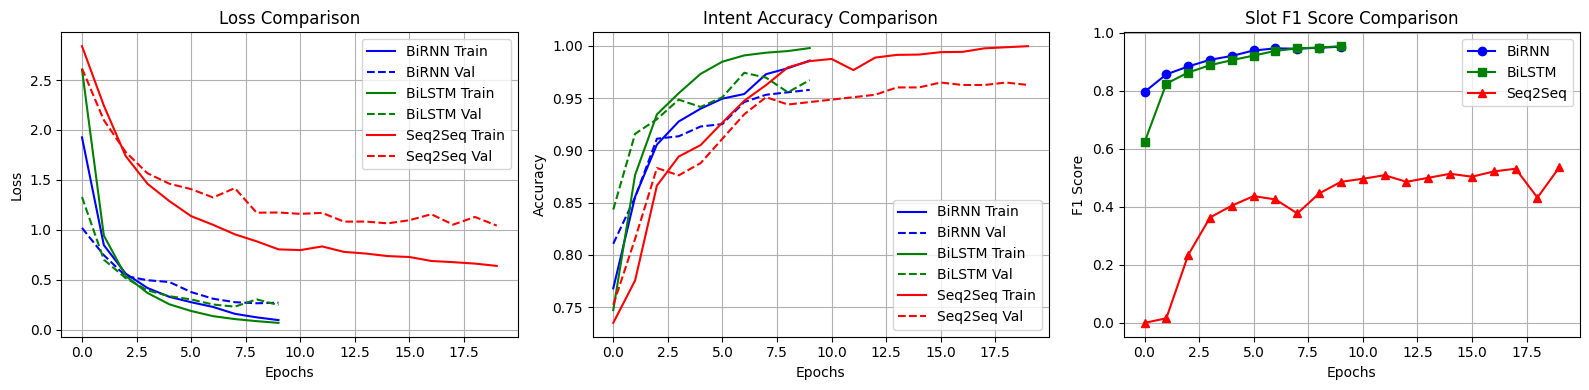


===== FINAL METRICS SUMMARY =====
Model           | Final Val Loss  | Final Val Acc   | Best Val F1    
----------------------------------------------------------------------
BiRNN           | 0.2692          | 0.9579          | 0.9526         
BiLSTM          | 0.2453          | 0.9673          | 0.9544         
Seq2Seq         | 1.0418          | 0.9626          | 0.5364         
----------------------------------------------------------------------


In [46]:
import matplotlib.pyplot as plt

def plot_comparison_subplots(hist1, hist2, hist3, name1="BiRNN", name2="BiLSTM", name3="Seq2Seq"):
    """
    Plots Loss, Intent Accuracy, and Slot F1 in a single row of 3 subplots.
    """

    # Create a figure with 1 row and 3 columns
    fig, axs = plt.subplots(1, 3, figsize=(16, 4))

    # --- SUBPLOT 1: LOSS ---
    # BiRNN
    axs[0].plot(hist1['train_loss'], label=f'{name1} Train', color='blue', linestyle='-')
    axs[0].plot(hist1['val_loss'], label=f'{name1} Val', color='blue', linestyle='--')
    # BiLSTM
    axs[0].plot(hist2['train_loss'], label=f'{name2} Train', color='green', linestyle='-')
    axs[0].plot(hist2['val_loss'], label=f'{name2} Val', color='green', linestyle='--')
    # Seq2Seq
    axs[0].plot(hist3['train_loss'], label=f'{name3} Train', color='red', linestyle='-')
    axs[0].plot(hist3['val_loss'], label=f'{name3} Val', color='red', linestyle='--')

    axs[0].set_title('Loss Comparison')
    axs[0].set_xlabel('Epochs')
    axs[0].set_ylabel('Loss')
    axs[0].legend()
    axs[0].grid(True)

    # --- SUBPLOT 2: INTENT ACCURACY ---
    # BiRNN
    axs[1].plot(hist1['train_intent_acc'], label=f'{name1} Train', color='blue', linestyle='-')
    axs[1].plot(hist1['val_intent_acc'], label=f'{name1} Val', color='blue', linestyle='--')
    # BiLSTM
    axs[1].plot(hist2['train_intent_acc'], label=f'{name2} Train', color='green', linestyle='-')
    axs[1].plot(hist2['val_intent_acc'], label=f'{name2} Val', color='green', linestyle='--')
    # Seq2Seq
    axs[1].plot(hist3['train_intent_acc'], label=f'{name3} Train', color='red', linestyle='-')
    axs[1].plot(hist3['val_intent_acc'], label=f'{name3} Val', color='red', linestyle='--')

    axs[1].set_title('Intent Accuracy Comparison')
    axs[1].set_xlabel('Epochs')
    axs[1].set_ylabel('Accuracy')
    axs[1].legend()
    axs[1].grid(True)

    # --- SUBPLOT 3: SLOT F1 SCORE ---
    # BiRNN
    axs[2].plot(hist1['val_slot_f1'], label=f'{name1}', color='blue', marker='o', linestyle='-')
    # BiLSTM
    axs[2].plot(hist2['val_slot_f1'], label=f'{name2}', color='green', marker='s', linestyle='-')
    # Seq2Seq
    axs[2].plot(hist3['val_slot_f1'], label=f'{name3}', color='red', marker='^', linestyle='-')

    axs[2].set_title('Slot F1 Score Comparison')
    axs[2].set_xlabel('Epochs')
    axs[2].set_ylabel('F1 Score')
    axs[2].legend()
    axs[2].grid(True)

    plt.tight_layout()
    plt.show()

def print_final_metrics(hist1, hist2, hist3, name1="BiRNN", name2="BiLSTM", name3="Seq2Seq"):
    """
    Prints a comparison table of the final epoch metrics.
    """
    def get_last(lst):
        return lst[-1] if lst else 0

    print(f"{'Model':<15} | {'Final Val Loss':<15} | {'Final Val Acc':<15} | {'Best Val F1':<15}")
    print("-" * 70)

    print(f"{name1:<15} | {get_last(hist1['val_loss']):<15.4f} | {get_last(hist1['val_intent_acc']):<15.4f} | {max(hist1['val_slot_f1']):<15.4f}")
    print(f"{name2:<15} | {get_last(hist2['val_loss']):<15.4f} | {get_last(hist2['val_intent_acc']):<15.4f} | {max(hist2['val_slot_f1']):<15.4f}")
    print(f"{name3:<15} | {get_last(hist3['val_loss']):<15.4f} | {get_last(hist3['val_intent_acc']):<15.4f} | {max(hist3['val_slot_f1']):<15.4f}")
    print("-" * 70)

# --- EXECUTE COMPARISON ---

# 1. Generate Subplots
plot_comparison_subplots(history, history_BiLSTM, history_seq2seq)

# 2. Print Summary Table
print("\n===== FINAL METRICS SUMMARY =====")
print_final_metrics(history, history_BiLSTM, history_seq2seq)

In [47]:
def run_comparison(
    sample_idx,
    test_df,
    birnn_intent_model,
    birnn_slot_model,
    bilstm_model,
    seq2seq_model,
    src_vocab,
    trg_vocab,
    intent_vocab,
    id2slot,
    id2intent,
    device="cpu"
):
    # ------------------------------
    # Load sample
    # ------------------------------
    sentence = test_df.iloc[sample_idx]["tokens"]
    true_intent = test_df.iloc[sample_idx]["intent"]
    true_slots_str = test_df.iloc[sample_idx]["slots"]

    tokens = sentence.split()
    true_slots = true_slots_str.split()

    print(f"\nRunning comparison on Test Sample #{sample_idx}...\n")

    # ================= SENTENCE =================
    print("=" * 120)
    print(f"{'SENTENCE':^120}")
    print("-" * 120)
    print(" ".join(tokens))
    print("=" * 120)

    # ======================================================
    #                    BiRNN
    # ======================================================
    word_ids = [src_vocab.get(t, src_vocab["<UNK>"]) for t in tokens]
    src_tensor = torch.tensor([word_ids]).to(device)
    mask = (src_tensor != 0)

    birnn_intent_model.eval()
    birnn_slot_model.eval()
    with torch.no_grad():
        birnn_slot_logits = birnn_slot_model(src_tensor, mask)
        birnn_intent_logits = birnn_intent_model(src_tensor, mask)

    birnn_intent = id2intent[birnn_intent_logits.argmax(1).item()]
    birnn_slots = birnn_slot_logits.argmax(2).squeeze(0).tolist()
    birnn_slots = [id2slot[i] for i in birnn_slots[:len(tokens)]]

    # ======================================================
    #                    BiLSTM
    # ======================================================
    bilstm_model.eval()
    with torch.no_grad():
        bilstm_slot_logits, bilstm_intent_logits = bilstm_model(src_tensor)

    bilstm_intent = id2intent[bilstm_intent_logits.argmax(1).item()]
    bilstm_slots = bilstm_slot_logits.argmax(2).squeeze(0).tolist()
    bilstm_slots = [id2slot[i] for i in bilstm_slots[:len(tokens)]]

    # ======================================================
    #                    Seq2Seq
    # ======================================================
    seq2seq_model.eval()

    max_len = len(tokens) + 10
    dummy_trg = torch.LongTensor(
        [[trg_vocab["<SOS>"]] + [trg_vocab["<PAD>"]] * (max_len - 1)]
    ).to(device)

    with torch.no_grad():
        seq_slots_logits, seq_intent_logits = seq2seq_model(
            src_tensor, dummy_trg, teacher_forcing_ratio=0
        )

    seq_intent = id2intent[seq_intent_logits.argmax(1).item()]

    seq_slot_ids = seq_slots_logits[:, 1:, :].argmax(2).squeeze(0).tolist()
    seq_slots = []
    for sid in seq_slot_ids:
        if sid in [trg_vocab["<EOS>"], trg_vocab["<PAD>"]]:
            break
        seq_slots.append(sid)

    if len(seq_slots) < len(tokens):
        seq_slots.extend([trg_vocab.get("O", trg_vocab["<PAD>"])] * (len(tokens) - len(seq_slots)))
    seq_slots = [id2slot[i] for i in seq_slots[:len(tokens)]]

    # ================= INTENT COMPARISON =================
    print("\n" + " " * 50 + "INTENT COMPARISON")
    print("-" * 120)
    print(f"{'Model':<15} | {'Predicted Intent':<30} | {'True Intent':<30} | Match")
    print("-" * 120)

    def intent_row(name, pred):
        match = "✅" if pred == true_intent else "❌"
        print(f"{name:<15} | {pred:<30} | {true_intent:<30} | {match}")

    print(f"{'True':<15} | {'-':<30} | {true_intent:<30} | -")
    intent_row("BiRNN", birnn_intent)
    intent_row("BiLSTM", bilstm_intent)
    intent_row("Seq2Seq", seq_intent)

    # ================= SLOT COMPARISON =================
    print("\n" + " " * 45 + "SLOT FILLING COMPARISON")
    print("-" * 120)
    print(
        f"{'Token':<15} | {'True Slot':<20} | {'BiRNN':<20} | {'BiLSTM':<20} | {'Seq2Seq':<20}"
    )
    print("-" * 120)

    for i in range(len(tokens)):
        print(
            f"{tokens[i]:<15} | "
            f"{true_slots[i]:<20} | "
            f"{birnn_slots[i]:<20} | "
            f"{bilstm_slots[i]:<20} | "
            f"{seq_slots[i]:<20}"
        )

    print("=" * 120)

random_idx = np.random.choice(len(test_df), 5, replace=False)

for idx in random_idx:
  run_comparison(
      sample_idx=idx,
      test_df=test_df,
      birnn_intent_model=intent_model,
      birnn_slot_model=slot_model,
      bilstm_model=LSTM_model,
      seq2seq_model=seq2seq,
      src_vocab=src_vocab,
      trg_vocab=trg_vocab,
      intent_vocab=intent_vocab,
      id2slot=id2slot,
      id2intent=id2intent,
      device=device
  )


Running comparison on Test Sample #95...

                                                        SENTENCE                                                        
------------------------------------------------------------------------------------------------------------------------
BOS please give me direct morning flights from pittsburgh to atlanta EOS

                                                  INTENT COMPARISON
------------------------------------------------------------------------------------------------------------------------
Model           | Predicted Intent               | True Intent                    | Match
------------------------------------------------------------------------------------------------------------------------
True            | -                              | atis_flight                    | -
BiRNN           | atis_ground_service            | atis_flight                    | ❌
BiLSTM          | atis_flight                    | atis_flight       